In [13]:
import copy
import time 
import torch
import sys, os
import numpy as np
import numpy.linalg as LA
from os.path import abspath, join, dirname, expanduser

sys.path.append(join(os.getcwd(), ".."))

from utils import *
from visuals import *
from pde_solvers import *

import matplotlib 
%matplotlib inline 

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
data_dir="/opt/SoRoSPT"
_labelsize=18
all_of_dem = os.listdir(data_dir)
print(all_of_dem)
fname = "092724_00_07_57_drag_cable_grav_10pcs_10.0N_spt_final.npz" #"092624_20_18_51_drag_cable_grav_10pcs_10.0N_spt_final.npz" #all_of_dem[-1]


['slow_dyna_dump.pt', '092824_15_53_59_10pcs_7fastpcs_3slowpcs_kp12.0_kd3.0_10.0N_spt.npz', '092824_14_48_10_drag_cable_grav_10pcs_10.0N_spt_final.npz', '092724_18_23_24_drag_cable_grav_6pcs_10.0N_spt_final.npz', '092724_17_58_31_drag_cable_grav_6pcs_10.0N_spt_final.npz', 'six_pcs_4fast_2slow_kp10_kd_2_runtime25.7mins.npz', 'five_axes_control_proper.eps', 'five_axes_control.eps', 'two_axes_control.eps']


In [8]:
def colors_and_gains(bundle, piece_type="fast"):
    # colors = iter(["red", "orange", "magenta", "olive", "purple", "pink", "green", "cyan", "black", "yellow"])
    colors_pos = iter(plt.cm.turbo_r(np.arange(0, 10))) #*.25, bundle.pieces)))
    colors_vel = iter(plt.cm.viridis_r(np.arange(0, 10))) #*.25, bundle.pieces)))
    # colors_vel = iter(["red", "orange", "magenta",  "green", "cyan", "black", "yellow", "olive", "purple", "pink"])

    runtime, controller =  bundle.runtime, bundle.controller 
    qbatch = bundle.qsecs.qbatch_fast if strcmp(piece_type, "fast") else bundle.qsecs.qbatch_slow 
    qdbatch = bundle.qsecs.qdbatch_fast if strcmp(piece_type, "fast") else bundle.qsecs.qdbatch_slow
    
    if strcmp(controller, "spt"):
        gains = rf'Kp: {bundle.backstep_p}, Kd: {bundle.backstep_d}, ${{\mathcal{{F}}}}_p^y$: {bundle.tip_load}N.'
    elif strcmp(controller, "PD"):
        gains = rf'Kp: {bundle.Kp}, KD: {bundle.Kd}, ${{\mathcal{{F}}}}_p^y$: {bundle.tip_load}N.'
    elif strcmp(controller, "PID"):
        gains = rf'Kp: {bundle.Kp}, KD: {bundle.Kd}, Ki: {bundle.Ki}, ${{\mathcal{{F}}}}_p^y$: {bundle.tip_load}N.' 
    
    return colors_pos, colors_vel, gains, qbatch, qdbatch

In [9]:
fname ="092724_17_58_31_drag_cable_grav_6pcs_10.0N_spt_final.npz"
bundle   = load_file(fname, data_dir, verbose=True)

j:  3
j:  4
 pieces: 6 | fast: 4 | slow: 2 | runtime: 18.02 mins | Kp: 10.0 | Kd: 2.0 | 


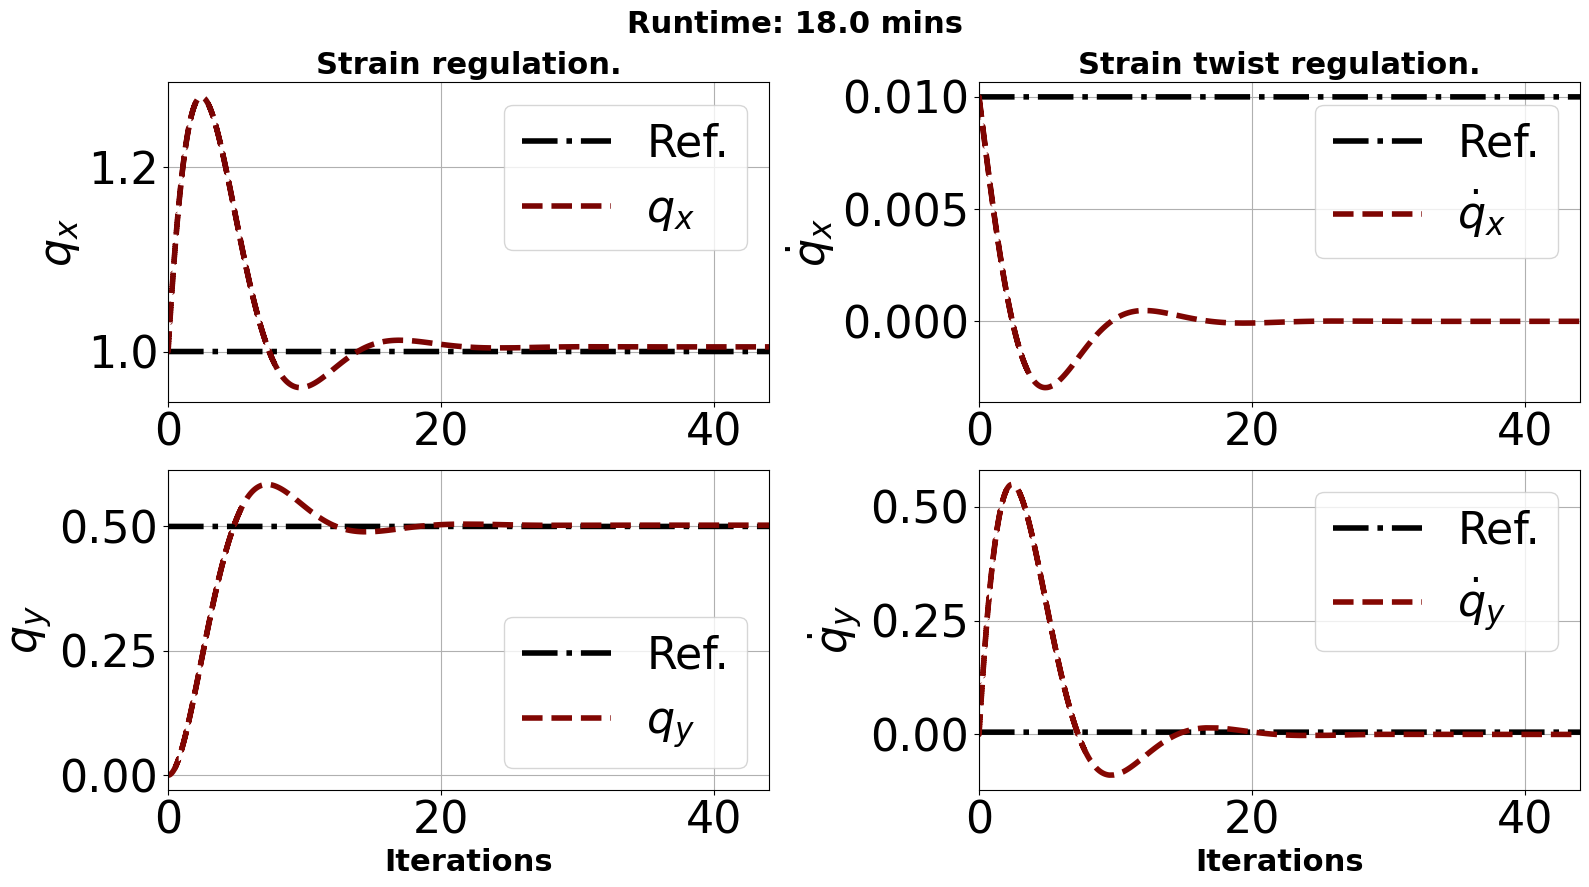

In [15]:
desired_strain = bundle.desired_strain
num_slow_pieces = bundle.num_slow_pieces
num_fast_pieces = bundle.num_fast_pieces
_fontdict = {'fontsize':22, 'fontweight':'bold'}
lsz = 32; lw=4
colors_pos, colors_vel, gains, qbatch, qdbatch  = colors_and_gains(bundle, "fast")
save = False;  savename = "two_axes_control"
# colors_pos = colors[0]; colors_vel=colors[1]
# qbatch = qbatchee[0]; qdbatch=qbatchee[1]

qd            = torch.tensor([[0, 0, 0, 1, desired_strain, 0]])
qd_dot        = torch.tensor([[0, 0, 0, 1, desired_strain, 0]]); 
qd_ddot        = torch.tensor([[0, 0, 0, 1, desired_strain, 0]])
    
qd_slow = torch.tile(qd.T, (num_slow_pieces, 1))
qd_dot_slow = torch.tile(qd_dot.T, (num_slow_pieces, 1))
qd_ddot_slow = torch.tile(qd_ddot.T, (num_slow_pieces, 1))

qd_fast = torch.tile(qd.T, (num_fast_pieces, 1))
qd_dot_fast = torch.tile(qd_dot.T, (num_fast_pieces, 1))
qd_ddot_fast = torch.tile(qd_ddot.T, (num_fast_pieces, 1))


fig = plt.figure(figsize=(16,9)); 
gs  = GridSpec(2, 2, fig)
ax  = [plt.subplot(gs[i]) for i in range(4)]

# nsol = 90*10**3
nsol = int(bundle.t_time.item()*10**3)
tref = np.linspace(0,bundle.t_time.item(),nsol) #.to(device)   #torch.linspace(0,90,nsol)  #np.linspace(0, len(qbatch), len(qbatch)) #/1000
plt_len = len(tref)

xlim = [0, bundle.t_time.item()]

roxes = ["Roll", "Pitch", "Yaw", "x", "y", "z", ]

j = 3
qbatch_all_secs = qbatch[:plt_len, slice(j, qbatch.shape[1], 6)].flatten()
tqb = np.linspace(0, len(qbatch_all_secs), len(qbatch_all_secs)) /1000
ax[0].plot(tref[:plt_len], [qd[0,j]]*plt_len, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
ax[0].plot(tqb, qbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ q_{roxes[j]} }}$")
ax[0].set_ylabel(rf"${{ q_{roxes[j]} }}$",  fontdict= {'fontsize':32, 'fontweight':'bold'})
# ax[0].set_xlabel(rf'Iterations',  fontdict=_fontdict)
ax[0].set_title(rf"Strain regulation.", _fontdict) #: ${{ q_{roxes[0]} }}$
ax[0].tick_params(axis='both', which='major', labelsize=lsz)
ax[0].tick_params(axis='both', which='minor', labelsize=lsz)
ax[0].set_xlim(xlim);  ax[0].grid('on') 
ax[0].legend(loc='upper right', fontsize=lsz) 
# qdot 
print('j: ', j)
qdbatch_all_secs = 0.01*qdbatch[:plt_len, slice(j, qdbatch.shape[1], 6)].flatten()
tqb = np.linspace(0, len(qdbatch_all_secs), len(qdbatch_all_secs)) /1000
ax[1].plot(tref[:plt_len], [0.01*qd_dot[0,j]]*plt_len, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
ax[1].plot(tqb, qdbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ \dot{{q}}_{roxes[j]} }}$")
ax[1].set_ylabel(rf"${{ \dot{{q}}_{roxes[j]} }}$",  fontdict= {'fontsize':32, 'fontweight':'bold'})
# ax[1].set_xlabel(rf'Iterations',  fontdict=_fontdict)
ax[1].set_title(rf"Strain twist regulation.", _fontdict) #: ${{ \dot{{q}}_{roxes[0]} }}$
ax[1].tick_params(axis='both', which='major', labelsize=lsz)
ax[1].tick_params(axis='both', which='minor', labelsize=lsz)
ax[1].set_xlim(xlim);  ax[1].grid('on') 
ax[1].legend(loc='upper right', fontsize=lsz) 

j = 4
qbatch_all_secs = qbatch[:plt_len, slice(j, qbatch.shape[1], 6)].flatten()
tqb = np.linspace(0, len(qbatch_all_secs), len(qbatch_all_secs)) /1000
ax[2].plot(tref[:plt_len], [qd[0,j]]*plt_len, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
ax[2].plot(tqb, qbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ q_{roxes[j]} }}$")
ax[2].set_ylabel(rf"${{ q_{roxes[j]} }}$",  fontdict= {'fontsize':32, 'fontweight':'bold'})
ax[2].set_xlabel(rf'Iterations',  fontdict=_fontdict)
# ax[2].set_title(rf"Strain regulation: ${{ q_{roxes[2]} }}$.", _fontdict)
ax[2].tick_params(axis='both', which='major', labelsize=lsz)
ax[2].tick_params(axis='both', which='minor', labelsize=lsz)
ax[2].set_xlim(xlim);  ax[2].grid('on') 
ax[2].legend(loc='lower right', fontsize=lsz) 
#qdot
print('j: ', j)
qbatch_all_secs = qdbatch[:plt_len, slice(j, qbatch.shape[1], 6)].flatten()
tqb = np.linspace(0, len(qbatch_all_secs), len(qbatch_all_secs)) /1000
ax[3].plot(tref[:plt_len], [0.01*qd_dot[0,j]]*plt_len, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
ax[3].plot(tqb, qbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ \dot{{q}}_{roxes[j]} }}$")
ax[3].set_ylabel(rf"${{ \dot{{q}}_{roxes[j]} }}$",  fontdict= {'fontsize':32, 'fontweight':'bold'})
ax[3].set_xlabel(rf'Iterations',  fontdict=_fontdict)
# ax[3].set_title(rf"Strain velocity regulation: ${{ \dot{{q}}_{roxes[2]} }}$.", _fontdict)
ax[3].tick_params(axis='both', which='major', labelsize=lsz)
ax[3].tick_params(axis='both', which='minor', labelsize=lsz)
ax[3].set_xlim(xlim);  ax[3].grid('on') 
ax[3].legend(loc='upper right', fontsize=lsz) 

fig.suptitle(rf"Runtime: {bundle.runtime//60} mins", fontsize=22, fontweight ='bold') #, fontdict=_fontdict)
plt.tight_layout()
print(rf" pieces: {bundle.num_pieces} | fast: {bundle.num_fast_pieces} | slow: {bundle.num_slow_pieces} | runtime: {bundle.runtime/60:.2f} mins | Kp: {bundle.backstep_p} | Kd: {bundle.backstep_d} | ")

if save:
    fig.savefig(join("/opt/SoRoSPT", savename+".eps"), bbox_inches='tight',  facecolor='w', format="eps", dpi=1000, transparent=True)

plt.show ()

In [16]:

fname ="six_pcs_4fast_2slow_kp10_kd_2_runtime25.7mins.npz"
bundle   = load_file(fname, data_dir, verbose=True)
bundle.perturb = 0.01 

desired_strain = bundle.desired_strain
num_slow_pieces = bundle.num_slow_pieces
num_fast_pieces = bundle.num_fast_pieces
_fontdict = {'fontsize':100, 'fontweight':'bold'}
lsz = 100; lw=32
colors_pos, colors_vel, gains, qbatch, qdbatch  = colors_and_gains(bundle, "fast")
save = True;  savename = "five_axes_control"

qd            = bundle.qd
qd_dot        = bundle.qd_dot * bundle.perturb 
qd_ddot        = bundle.qd_ddot
    
qd_slow = np.tile(qd.T, (num_slow_pieces, 1))
qd_dot_slow = np.tile(qd_dot.T, (num_slow_pieces, 1))
qd_ddot_slow = np.tile(qd_ddot.T, (num_slow_pieces, 1))

qd_fast = np.tile(qd.T, (num_fast_pieces, 1))
qd_dot_fast = np.tile(qd_dot.T, (num_fast_pieces, 1))
qd_ddot_fast = np.tile(qd_ddot.T, (num_fast_pieces, 1))


fig = plt.figure(figsize=(100,80)); 
import matplotlib.gridspec as Gridspec
gs  = Gridspec.GridSpec(5, 2, fig)
ax  = [plt.subplot(gs[i]) for i in range(10)]

# nsol = 90*10**3
nsol = int(bundle.t_time.item()*10**3)
tref = np.linspace(0,bundle.t_time.item(),nsol) 
plt_len = len(tref)

xlim = [0, bundle.t_time.item()]

roxes = ["\theta", "\phi", "\psi", "x", "y", "z"]

ax[0].set_title(rf"Strain regulation.", _fontdict) 
ax[1].set_title(rf"Strain twist regulation.", _fontdict) #: ${{ \dot{{q}}_{roxes[0]} }}$

ax_ind = 0
for j in range(1, 6):
    qbatch_all_secs = qbatch[:plt_len, slice(j, qbatch.shape[1], 6)].flatten()
    tqb = np.linspace(0, len(qbatch_all_secs), len(qbatch_all_secs)) /1000
    ax[ax_ind].plot(tref[:plt_len], [qd[0,j]]*plt_len, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
    ax[ax_ind].plot(tqb, qbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ q_{roxes[j]} }}$")
    ax[ax_ind].set_ylabel(rf"${{ q_{roxes[j]} }}$",  fontdict= _fontdict)
    ax[ax_ind].tick_params(axis='both', which='major', labelsize=lsz)
    ax[ax_ind].tick_params(axis='both', which='minor', labelsize=lsz)
    ax[ax_ind].set_xlim(xlim);  
    ax[ax_ind].grid('on') 
    ax[ax_ind].legend(loc='best', fontsize=lsz) 
    ax_ind += 1
    # qdot 
    qdbatch_all_secs = qdbatch[:plt_len, slice(j, qdbatch.shape[1], 6)].flatten()
    ax[ax_ind].plot(tref[:plt_len], [qd_dot[0,j]]*plt_len, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
    ax[ax_ind].plot(tqb, qdbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ \dot{{q}}_{roxes[j]} }}$")
    ax[ax_ind].set_ylabel(rf"${{ \dot{{q}}_{roxes[j]} }}$",  fontdict= _fontdict)
    ax[ax_ind].tick_params(axis='both', which='major', labelsize=lsz)
    ax[ax_ind].tick_params(axis='both', which='minor', labelsize=lsz)
    ax[ax_ind].set_xlim(xlim);  
    ax[ax_ind].grid('on') 
    ax[ax_ind].legend(loc='best', fontsize=lsz) 
    ax_ind += 1

# decorations
ax[0].set_title(rf"Strain regulation.", _fontdict) #: {{ q_{roxes[j]} }}$
ax[1].set_title(rf"Strain twist regulation.", _fontdict) #: ${{ q_{roxes[j]} }}$
ax[8].set_xlabel(rf'Iterations',  fontdict=_fontdict)
ax[9].set_xlabel(rf'Iterations',  fontdict=_fontdict)

print(rf" pieces: {bundle.num_pieces} | fast: {bundle.num_fast_pieces} | slow: {bundle.num_slow_pieces} | runtime: {bundle.runtime/60:.2f} mins | Kp: {bundle.backstep_p} | Kd: {bundle.backstep_d} | ")
plt.tight_layout()

if save:
    fig.savefig(join("/opt/SoRoSPT", savename+".eps"), bbox_inches='tight',  facecolor='w', format="eps", dpi=1000, transparent=True)

plt.show ()

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2093200/2119098982.py:38: SyntaxWarning: invalid escape sequence '\p'
  roxes = ["\theta", "\phi", "\psi", "x", "y", "z"]
/tmp/ipykernel_2093200/2119098982.py:38: SyntaxWarning: invalid escape sequence '\p'
  roxes = ["\theta", "\phi", "\psi", "x", "y", "z"]


 pieces: 6 | fast: 4 | slow: 2 | runtime: 25.70 mins | Kp: 10.0 | Kd: 2.0 | 


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [37]:
print(rf" pieces: {bundle.num_pieces} | fast: {bundle.num_fast_pieces} | slow: {bundle.num_slow_pieces} | runtime: {bundle.runtime/60:.2f} mins | Kp: {bundle.backstep_p} | Kd: {bundle.backstep_d} | ")

 pieces: 6 | fast: 4 | slow: 2 | runtime: 25.70 mins | Kp: 10.0 | Kd: 2.0 | 


In [23]:
fname = "092824_14_48_10_drag_cable_grav_10pcs_10.0N_spt_final.npz"
fname = "092824_15_53_59_10pcs_7fastpcs_3slowpcs_kp12.0_kd3.0_10.0N_spt.npz"
bundle   = load_file(fname, data_dir, verbose=True)

desired_strain = bundle.desired_strain
num_slow_pieces = bundle.num_slow_pieces
num_fast_pieces = bundle.num_fast_pieces
_fontdict = {'fontsize':100, 'fontweight':'bold'}
lsz = 100; lw=22
colors_pos, colors_vel, gains, qbatch, qdbatch  = colors_and_gains(bundle, "fast")
save = False;  savename = "five_axes_control_proper"
    
fig = plt.figure(figsize=(100,80)); 
import matplotlib.gridspec as Gridspec
gs  = Gridspec.GridSpec(5, 2, fig)
ax  = [plt.subplot(gs[i]) for i in range(10)]

# nsol = 90*10**3
nsol = int(bundle.t_time.item()*10**3)
tref = np.linspace(0,bundle.t_time.item(),nsol) 
plt_len = len(tref)

qd            = bundle.qd; qd = np.tile(qd, [plt_len, bundle.num_fast_pieces])
qd_dot        = bundle.qd_dot * bundle.perturb; qd_dot = np.tile(qd_dot, [plt_len, bundle.num_fast_pieces])

xlim = [0, bundle.t_time.item()]

roxes = ["\theta", "\phi", "\psi", "x", "y", "z"]

ax[0].set_title(rf"Strain regulation.", _fontdict) 
ax[1].set_title(rf"Strain twist regulation.", _fontdict) #: ${{ \dot{{q}}_{roxes[0]} }}$

ax_ind = 0
for j in range(1, 6):
    qbatch_all_secs = qbatch[:plt_len, slice(j, qbatch.shape[1], 6)].flatten()
    qd_all_secs = qd[:plt_len, slice(j, qd.shape[1], 6)].flatten()
    tqb = np.linspace(0, len(qbatch_all_secs), len(qbatch_all_secs)) /1000
    ax[ax_ind].plot(tqb, qd_all_secs, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
    ax[ax_ind].plot(tqb, qbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ q_{roxes[j]} }}$")
    ax[ax_ind].set_ylabel(rf"${{ q_{roxes[j]} }}$",  fontdict= _fontdict)
    ax[ax_ind].tick_params(axis='both', which='major', labelsize=lsz)
    ax[ax_ind].tick_params(axis='both', which='minor', labelsize=lsz)
    ax[ax_ind].set_xlim(xlim);  
    ax[ax_ind].grid('on') 
    ax[ax_ind].legend(loc='best', fontsize=lsz) 
    ax_ind += 1
    # qdot 
    qdbatch_all_secs = qdbatch[:plt_len, slice(j, qdbatch.shape[1], 6)].flatten()
    qd_dot_all_secs = qd_dot[:plt_len, slice(j, qd_dot.shape[1], 6)].flatten()
    ax[ax_ind].plot(tqb, qd_dot_all_secs, linewidth=lw, color='k', linestyle="-.",label=f"Ref.")
    ax[ax_ind].plot(tqb, qdbatch_all_secs, linewidth=lw, color=next(colors_pos), linestyle="--",label=rf"${{ \dot{{q}}_{roxes[j]} }}$")
    ax[ax_ind].set_ylabel(rf"${{ \dot{{q}}_{roxes[j]} }}$",  fontdict= _fontdict)
    ax[ax_ind].tick_params(axis='both', which='major', labelsize=lsz)
    ax[ax_ind].tick_params(axis='both', which='minor', labelsize=lsz)
    ax[ax_ind].set_xlim(xlim);  
    ax[ax_ind].grid('on') 
    ax[ax_ind].legend(loc='best', fontsize=lsz) 
    ax_ind += 1

# decorations
ax[0].set_title(rf"Strain regulation.", _fontdict) #: {{ q_{roxes[j]} }}$
ax[1].set_title(rf"Strain twist regulation.", _fontdict) #: ${{ q_{roxes[j]} }}$
ax[8].set_xlabel(rf'Iterations',  fontdict=_fontdict)
ax[9].set_xlabel(rf'Iterations',  fontdict=_fontdict)

plt.tight_layout()

print(rf" pieces: {bundle.num_pieces} | fast: {bundle.num_fast_pieces} | slow: {bundle.num_slow_pieces} | runtime: {bundle.runtime/60:.2f} mins | Kp: {bundle.backstep_p} | Kd: {bundle.backstep_d} | ")

if save:
    fig.savefig(join("/opt/SoRoSPT", savename+".eps"), bbox_inches='tight',  facecolor='w', format="eps", dpi=1000, transparent=True)

plt.show ()

<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2093200/1495474331.py:29: SyntaxWarning: invalid escape sequence '\p'
  roxes = ["\theta", "\phi", "\psi", "x", "y", "z"]
/tmp/ipykernel_2093200/1495474331.py:29: SyntaxWarning: invalid escape sequence '\p'
  roxes = ["\theta", "\phi", "\psi", "x", "y", "z"]


 pieces: 10 | fast: 7 | slow: 3 | runtime: 32.39 mins | Kp: 3.0 | Kd: 2.0 | 
